# AOA Modeling Baseline

This notebook builds baseline models from the engineered AoA feature sets.

这个 notebook 用来基于已经构造好的 AoA 特征集建立第一轮 baseline 模型。


## 1. Modeling goal

We compare:
- `FeatureSet-A`: engineered numeric features only
- `FeatureSet-B`: `FeatureSet-A` plus cleaned categorical features

We also compare two modeling views:
- direct 3-class classification for `Age_Group`
- regression on `AoA_final`, then bucket back into age groups

这里主要比较两件事：
- `FeatureSet-A`：只使用 engineered numeric features
- `FeatureSet-B`：在 `FeatureSet-A` 基础上加入清洗后的类别特征

同时也比较两种建模思路：
- 直接对 `Age_Group` 做三分类
- 先回归预测 `AoA_final`，再按年龄区间切回分类标签


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeClassifier, Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

ROOT = Path.cwd()
if ROOT.name == 'iteration2':
    ROOT = ROOT.parent.parent

FEATURE_A_PATH = ROOT / 'data/processed/iteration2/AoA_featureset_a_v3_freq2.csv'
FEATURE_B_PATH = ROOT / 'data/processed/iteration2/AoA_featureset_b_v3_freq2.csv'

FEATURE_A_PATH, FEATURE_B_PATH


(PosixPath('/Users/datong/Documents/5120/Nurodiversity inclusive design/data/TP10_DS/data/processed/iteration2/AoA_featureset_a_v3_freq2.csv'),
 PosixPath('/Users/datong/Documents/5120/Nurodiversity inclusive design/data/TP10_DS/data/processed/iteration2/AoA_featureset_b_v3_freq2.csv'))

## 2. Load engineered feature sets

We use the exported CSV files from the feature engineering notebook.

这里直接读取 feature engineering notebook 导出的 CSV 文件。


In [2]:
feature_a_df = pd.read_csv(FEATURE_A_PATH)
feature_b_df = pd.read_csv(FEATURE_B_PATH)

print('FeatureSet-A:', feature_a_df.shape)
print('FeatureSet-B:', feature_b_df.shape)
display(feature_a_df.head())


FeatureSet-A: (9997, 15)
FeatureSet-B: (9997, 18)


,Word,log_freq_pm,Nletters,Nphon,Nsyll,Perc_known_final,letters_per_syll,phon_per_syll,letters_per_phon,letters_x_syll,phon_x_syll,is_lemma_match,lemma_length_diff,AoA_final,Age_Group
0,a,9.924088,1,1,1,1.000000,1.000000,1.000000,1.000000,1,1,1,0,2.893384,below_6
1,abandon,2.208059,7,7,3,1.000000,2.333333,2.333333,1.000000,21,21,1,0,8.320000,age_8_plus
2,abandoned,2.659848,9,8,3,1.000000,3.000000,2.666667,1.125000,27,24,0,2,8.320000,age_8_plus
3,abbey,1.429467,5,3,2,0.857143,2.500000,1.500000,1.666667,10,6,1,0,13.060000,age_8_plus
4,abdomen,1.470852,7,7,3,1.000000,2.333333,2.333333,1.000000,21,21,1,0,8.610000,age_8_plus


## 3. Train/test split

We use the same stratified split for all classification experiments so the comparisons stay fair.

为了公平比较不同特征集和模型，这里对所有分类实验使用同一个按 `Age_Group` 分层的 train/test split。


In [3]:
split_df = feature_b_df[['Word', 'Age_Group']].copy()
train_idx, test_idx = train_test_split(
    split_df.index,
    test_size=0.2,
    stratify=split_df['Age_Group'],
    random_state=42,
)

print('train size:', len(train_idx))
print('test size:', len(test_idx))
display((feature_b_df.loc[train_idx, 'Age_Group'].value_counts(normalize=True) * 100).round(2).to_frame('train_pct'))
display((feature_b_df.loc[test_idx, 'Age_Group'].value_counts(normalize=True) * 100).round(2).to_frame('test_pct'))


train size: 7997
test size: 2000


,train_pct
Age_Group,
age_8_plus,42.47
below_6,30.36
age_6_8,27.17


,test_pct
Age_Group,
age_8_plus,42.45
below_6,30.35
age_6_8,27.20


## 4. Helper functions

These helper functions keep the experiments compact and make it easier to compare models side by side.

下面的辅助函数主要是为了让后续实验更紧凑，也方便把不同模型结果并排比较。


In [4]:
def age_bucket_from_aoa(x):
    if x < 6:
        return 'below_6'
    if x < 8:
        return 'age_6_8'
    return 'age_8_plus'


def prepare_xy(df, feature_cols, target_col, train_idx, test_idx):
    X_train = df.loc[train_idx, feature_cols].copy()
    X_test = df.loc[test_idx, feature_cols].copy()
    y_train = df.loc[train_idx, target_col].copy()
    y_test = df.loc[test_idx, target_col].copy()
    return X_train, X_test, y_train, y_test


def evaluate_classifier(name, model, X_train, X_test, y_train, y_test, labels):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, pred, labels=labels)
    summary = {
        'model': name,
        'accuracy': acc,
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
    return summary, pred, cm, report


def show_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()


labels = ['below_6', 'age_6_8', 'age_8_plus']
label_encoder = LabelEncoder()
label_encoder.fit(labels)


LabelEncoder()

## 5. FeatureSet-A classification baselines

We start with numeric engineered features only.

这里先从只包含数值特征的 `FeatureSet-A` 开始。


RidgeClassifier_A
              precision    recall  f1-score   support

     age_6_8       0.33      0.00      0.00       544
  age_8_plus       0.60      0.86      0.71       849
     below_6       0.56      0.72      0.63       607

    accuracy                           0.58      2000
   macro avg       0.50      0.53      0.45      2000
weighted avg       0.52      0.58      0.49      2000



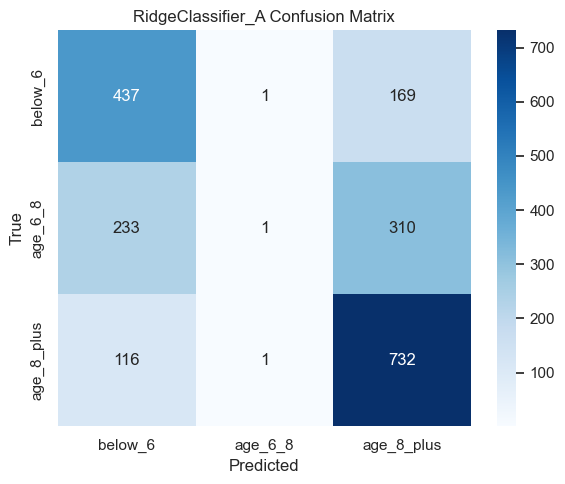

XGBClassifier_A
              precision    recall  f1-score   support

     age_6_8       0.38      0.19      0.25       544
  age_8_plus       0.65      0.82      0.72       849
     below_6       0.58      0.64      0.61       607

    accuracy                           0.59      2000
   macro avg       0.54      0.55      0.53      2000
weighted avg       0.56      0.59      0.56      2000



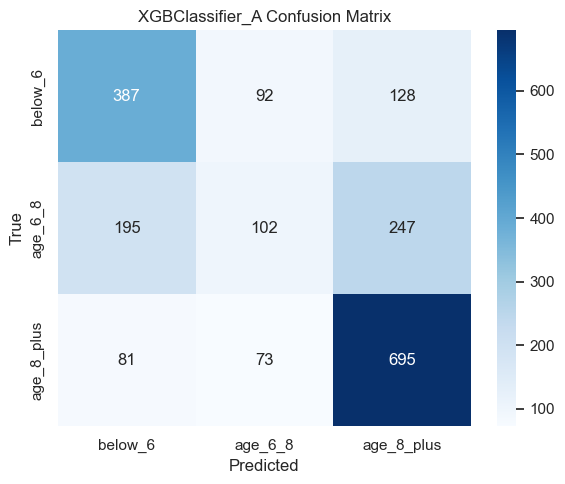

,model,accuracy,macro_f1,weighted_f1
1,XGBClassifier_A,0.592,0.5284,0.5609
0,RidgeClassifier_A,0.585,0.4473,0.4931


In [5]:
feature_a_cols = [c for c in feature_a_df.columns if c not in ['Word', 'AoA_final', 'Age_Group']]
Xa_train, Xa_test, ya_train, ya_test = prepare_xy(feature_a_df, feature_a_cols, 'Age_Group', train_idx, test_idx)

ridge_a = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RidgeClassifier(alpha=1.0)),
])

xgb_a = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
    )),
])

results_a = []

summary, pred, cm, report = evaluate_classifier('RidgeClassifier_A', ridge_a, Xa_train, Xa_test, ya_train, ya_test, labels)
results_a.append(summary)
print('RidgeClassifier_A')
print(classification_report(ya_test, pred, zero_division=0))
show_confusion_matrix(cm, labels, 'RidgeClassifier_A Confusion Matrix')

xgb_a.fit(Xa_train, label_encoder.transform(ya_train))
pred_xgb_a = label_encoder.inverse_transform(xgb_a.predict(Xa_test))
acc_xgb_a = accuracy_score(ya_test, pred_xgb_a)
report_xgb_a = classification_report(ya_test, pred_xgb_a, output_dict=True, zero_division=0)
cm_xgb_a = confusion_matrix(ya_test, pred_xgb_a, labels=labels)
results_a.append({
    'model': 'XGBClassifier_A',
    'accuracy': acc_xgb_a,
    'macro_f1': report_xgb_a['macro avg']['f1-score'],
    'weighted_f1': report_xgb_a['weighted avg']['f1-score'],
})
print('XGBClassifier_A')
print(classification_report(ya_test, pred_xgb_a, zero_division=0))
show_confusion_matrix(cm_xgb_a, labels, 'XGBClassifier_A Confusion Matrix')

results_a_df = pd.DataFrame(results_a).sort_values('macro_f1', ascending=False)
display(results_a_df.round(4))


## 6. FeatureSet-B classification baselines

Now we test whether cleaned categorical features improve the classifier.

接着测试加入清洗后类别特征的 `FeatureSet-B`，看看它们能不能进一步提升分类效果。


RidgeClassifier_B
              precision    recall  f1-score   support

     age_6_8       0.62      0.01      0.02       544
  age_8_plus       0.61      0.87      0.72       849
     below_6       0.56      0.73      0.64       607

    accuracy                           0.59      2000
   macro avg       0.60      0.54      0.46      2000
weighted avg       0.60      0.59      0.50      2000



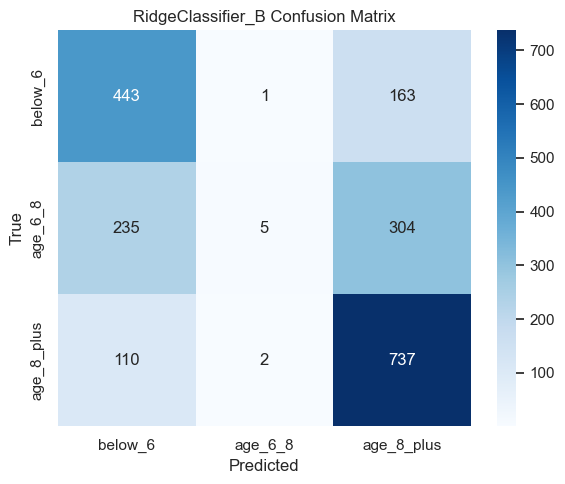

XGBClassifier_B
              precision    recall  f1-score   support

     age_6_8       0.39      0.19      0.26       544
  age_8_plus       0.65      0.82      0.73       849
     below_6       0.59      0.66      0.63       607

    accuracy                           0.60      2000
   macro avg       0.55      0.56      0.54      2000
weighted avg       0.56      0.60      0.57      2000



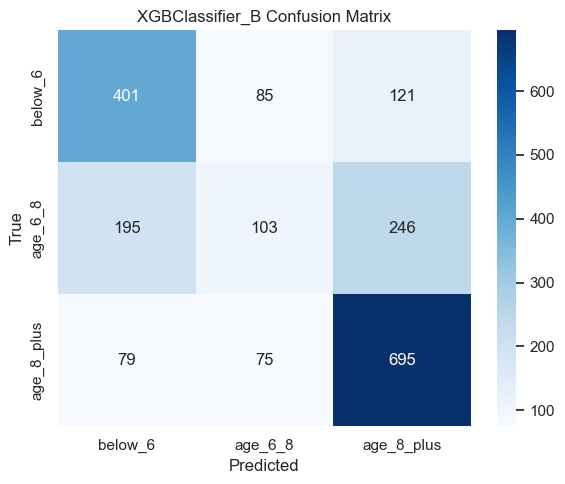

,model,accuracy,macro_f1,weighted_f1
1,XGBClassifier_B,0.5995,0.5361,0.5681
0,RidgeClassifier_B,0.5925,0.4571,0.5025


In [6]:
feature_b_cols = [c for c in feature_b_df.columns if c not in ['Word', 'AoA_final', 'Age_Group']]
numeric_b_cols = feature_b_df[feature_b_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_b_cols = [c for c in feature_b_cols if c not in numeric_b_cols]
Xb_train, Xb_test, yb_train, yb_test = prepare_xy(feature_b_df, feature_b_cols, 'Age_Group', train_idx, test_idx)

pre_b = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_b_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_b_cols),
])

ridge_b = Pipeline([
    ('preprocess', pre_b),
    ('model', RidgeClassifier(alpha=1.0)),
])

xgb_b = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), numeric_b_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_b_cols),
    ])),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
    )),
])

results_b = []

summary, pred, cm, report = evaluate_classifier('RidgeClassifier_B', ridge_b, Xb_train, Xb_test, yb_train, yb_test, labels)
results_b.append(summary)
print('RidgeClassifier_B')
print(classification_report(yb_test, pred, zero_division=0))
show_confusion_matrix(cm, labels, 'RidgeClassifier_B Confusion Matrix')

xgb_b.fit(Xb_train, label_encoder.transform(yb_train))
pred_xgb_b = label_encoder.inverse_transform(xgb_b.predict(Xb_test))
acc_xgb_b = accuracy_score(yb_test, pred_xgb_b)
report_xgb_b = classification_report(yb_test, pred_xgb_b, output_dict=True, zero_division=0)
cm_xgb_b = confusion_matrix(yb_test, pred_xgb_b, labels=labels)
results_b.append({
    'model': 'XGBClassifier_B',
    'accuracy': acc_xgb_b,
    'macro_f1': report_xgb_b['macro avg']['f1-score'],
    'weighted_f1': report_xgb_b['weighted avg']['f1-score'],
})
print('XGBClassifier_B')
print(classification_report(yb_test, pred_xgb_b, zero_division=0))
show_confusion_matrix(cm_xgb_b, labels, 'XGBClassifier_B Confusion Matrix')

results_b_df = pd.DataFrame(results_b).sort_values('macro_f1', ascending=False)
display(results_b_df.round(4))


## 7. Regression then bucket

Because AoA is originally continuous, regression may fit the problem more naturally than direct classification. We test that idea with `FeatureSet-A` first.

由于 AoA 本质上是连续变量，回归有时会比直接分类更贴合问题本身。这里先用 `FeatureSet-A` 测试这种思路。


RidgeReg_A
              precision    recall  f1-score   support

     age_6_8       0.36      0.59      0.44       544
  age_8_plus       0.73      0.68      0.70       849
     below_6       0.71      0.36      0.48       607

    accuracy                           0.56      2000
   macro avg       0.60      0.54      0.54      2000
weighted avg       0.62      0.56      0.56      2000



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


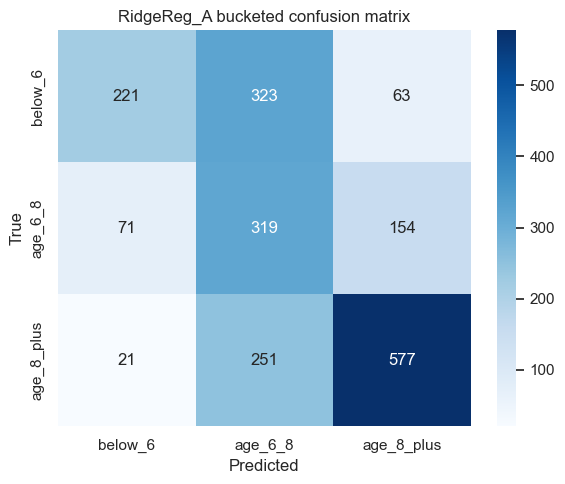

XGBReg_A
              precision    recall  f1-score   support

     age_6_8       0.37      0.49      0.42       544
  age_8_plus       0.70      0.71      0.70       849
     below_6       0.69      0.47      0.56       607

    accuracy                           0.58      2000
   macro avg       0.58      0.56      0.56      2000
weighted avg       0.60      0.58      0.58      2000



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


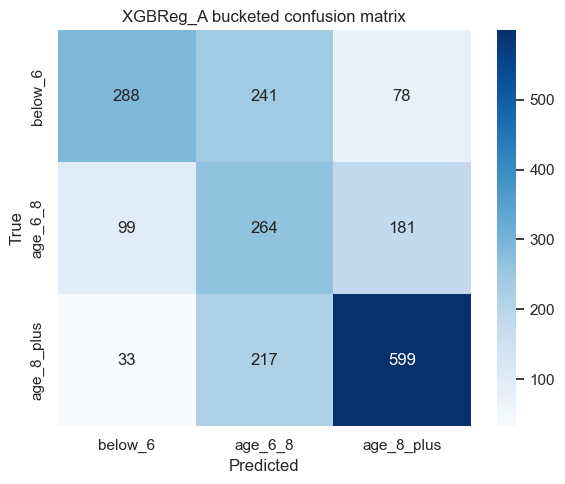

,model,rmse,mae,bucket_accuracy
1,XGBReg_A,1.8922,1.5038,0.5755
0,RidgeReg_A,1.8741,1.4999,0.5585


In [7]:
Xa_reg_train, Xa_reg_test, ya_reg_train, ya_reg_test = prepare_xy(feature_a_df, feature_a_cols, 'AoA_final', train_idx, test_idx)

ridge_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0)),
])

xgb_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42,
    )),
])

regression_rows = []
for name, model in [('RidgeReg_A', ridge_reg), ('XGBReg_A', xgb_reg)]:
    model.fit(Xa_reg_train, ya_reg_train)
    pred_aoa = model.predict(Xa_reg_test)
    pred_bucket = pd.Series(pred_aoa).apply(age_bucket_from_aoa)
    true_bucket = ya_reg_test.apply(age_bucket_from_aoa)
    row = {
        'model': name,
        'rmse': mean_squared_error(ya_reg_test, pred_aoa, squared=False),
        'mae': mean_absolute_error(ya_reg_test, pred_aoa),
        'bucket_accuracy': accuracy_score(true_bucket, pred_bucket),
    }
    regression_rows.append(row)
    print(name)
    print(classification_report(true_bucket, pred_bucket, zero_division=0))
    cm = confusion_matrix(true_bucket, pred_bucket, labels=labels)
    show_confusion_matrix(cm, labels, f'{name} bucketed confusion matrix')

regression_results_df = pd.DataFrame(regression_rows).sort_values('bucket_accuracy', ascending=False)
display(regression_results_df.round(4))


## 8. Compare model families

This summary table makes it easier to see whether feature expansion or model choice is helping more.

这张汇总表的作用是帮助我们判断：提升主要来自于特征扩展，还是来自于模型更换。


In [8]:
all_classification_results = pd.concat([
    results_a_df.assign(feature_set='A'),
    results_b_df.assign(feature_set='B'),
], ignore_index=True)

display(all_classification_results.sort_values(['macro_f1', 'accuracy'], ascending=False).round(4))
display(regression_results_df.round(4))


,model,accuracy,macro_f1,weighted_f1,feature_set
2,XGBClassifier_B,0.5995,0.5361,0.5681,B
0,XGBClassifier_A,0.5920,0.5284,0.5609,A
3,RidgeClassifier_B,0.5925,0.4571,0.5025,B
1,RidgeClassifier_A,0.5850,0.4473,0.4931,A


,model,rmse,mae,bucket_accuracy
1,XGBReg_A,1.8922,1.5038,0.5755
0,RidgeReg_A,1.8741,1.4999,0.5585


## 9. Next step

After the first baseline round, the next improvements should focus on:
- boundary-heavy evaluation near the `6` and `8` cut points
- comparing `FeatureSet-A` and `FeatureSet-B` more systematically with cross-validation
- testing ordinal-friendly modeling if the middle class remains ambiguous

第一轮 baseline 跑完之后，下一步最值得做的是：
- 专门关注 `6` 和 `8` 岁边界附近样本的表现
- 用 cross-validation 更系统地比较 `FeatureSet-A` 和 `FeatureSet-B`
- 如果中间类还是模糊，就继续尝试更适合有序标签的模型
